# Advanced Crop Recommendation Modeling

In this notebook, we train advanced machine learning classifiers including **XGBoost, LightGBM, and CatBoost**, and compare them against the best performing models from the previous exploration (**Random Forest, Extra Trees**). We evaluate them on standard classification metrics, explain the model predictions using **SHAP and LIME**, and save the best performing model.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import ExtraTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## 2. Load Dataset

In [2]:
# Load data using the symlink dataset path
crop = pd.read_csv("data 2/merged_crop_recommendation.csv")
print(f"Dataset Shape: {crop.shape}")
crop.head()

Dataset Shape: (6600, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Data Preprocessing & Target Encoding

To prevent errors in XGBoost/LightGBM, we encode target class labels to be 0-indexed (from 0 to 21).

In [3]:
crop_dict = {
    'rice': 1, 'maize': 2, 'jute': 3, 'cotton': 4, 'coconut': 5,
    'papaya': 6, 'orange': 7, 'apple': 8, 'muskmelon': 9, 'watermelon': 10,
    'grapes': 11, 'mango': 12, 'banana': 13, 'pomegranate': 14, 'lentil': 15,
    'blackgram': 16, 'mungbean': 17, 'mothbeans': 18, 'pigeonpeas': 19,
    'kidneybeans': 20, 'chickpea': 21, 'coffee': 22
}

# Map labels to 0-indexed integer targets (0 to 21) for compatibility with advanced boosting models
crop['crop_num'] = crop['label'].map(crop_dict) - 1
crop_names_dict = {v - 1: k.capitalize() for k, v in crop_dict.items()}
crop.drop(['label'], axis=1, inplace=True)
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,0
1,85,58,41,21.770462,80.319644,7.038096,226.655537,0
2,60,55,44,23.004459,82.320763,7.840207,263.964248,0
3,74,35,40,26.491096,80.158363,6.980401,242.864034,0
4,78,42,42,20.130175,81.604873,7.628473,262.717340,0


## 4. Train-Test Split & Feature Scaling

We perform a stratified split to ensure equal representation of all crop labels in both train and test splits.

In [4]:
X = crop.drop(['crop_num'], axis=1)
y = crop['crop_num']

# Stratified split for class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Min-Max scaler
ms = MinMaxScaler()
X_train = ms.fit_transform(X_train)
X_test = ms.transform(X_test)

print(f"Train set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Train set size: 5280, Test set size: 1320


## 5. Model Definition and Training

We define a dictionary of classifiers including Random Forest, Extra Trees, and the advanced gradient boosters (XGBoost, LightGBM, and CatBoost).

In [5]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)
    
    acc = accuracy_score(y_test, ypred)
    prec = precision_score(y_test, ypred, average='weighted')
    rec = recall_score(y_test, ypred, average='weighted')
    f1 = f1_score(y_test, ypred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    print(f"{name} Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print("-"*50)

results_df = pd.DataFrame(results)
results_df

Training Random Forest...


Random Forest Accuracy: 1.0000 | F1: 1.0000
--------------------------------------------------
Training Extra Trees...
Extra Trees Accuracy: 1.0000 | F1: 1.0000
--------------------------------------------------
Training XGBoost...


XGBoost Accuracy: 1.0000 | F1: 1.0000
--------------------------------------------------
Training LightGBM...


LightGBM Accuracy: 1.0000 | F1: 1.0000
--------------------------------------------------
Training CatBoost...


CatBoost Accuracy: 1.0000 | F1: 1.0000
--------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,1.0,1.0,1.0,1.0
1,Extra Trees,1.0,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0,1.0
3,LightGBM,1.0,1.0,1.0,1.0
4,CatBoost,1.0,1.0,1.0,1.0


## 6. Model Performance Comparison Visualization

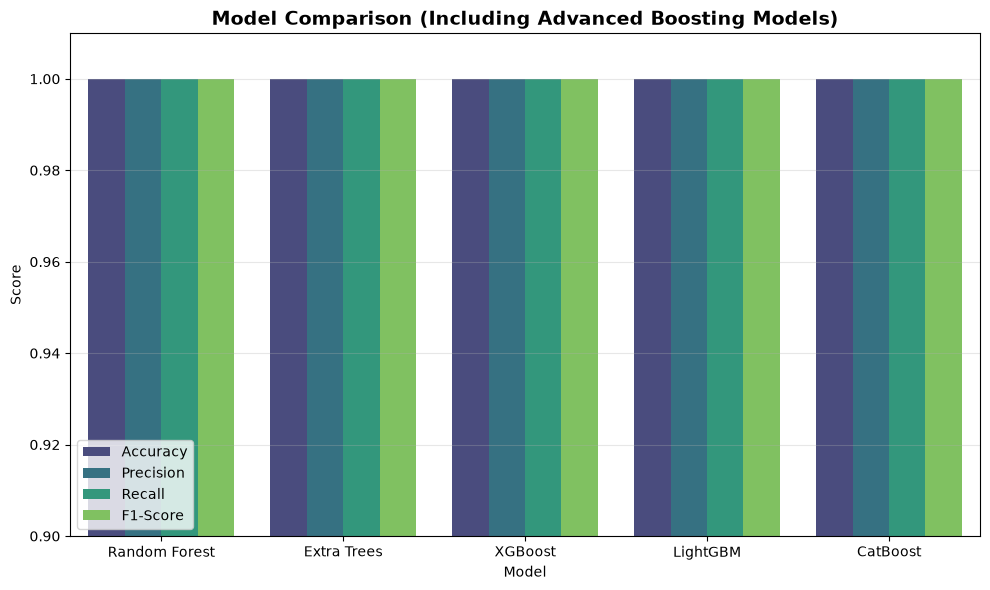

In [6]:
plt.figure(figsize=(10, 6))
melted_df = pd.melt(results_df, id_vars="Model", var_name="Metric", value_name="Value")
sns.barplot(x="Model", y="Value", hue="Metric", data=melted_df, palette="viridis")
plt.title("Model Comparison (Including Advanced Boosting Models)", fontsize=14, fontweight='bold')
plt.ylim(0.9, 1.01)
plt.ylabel("Score")
plt.legend(loc='lower left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("advanced_model_comparison.png", dpi=300)
plt.show()

## 7. Save the Best Performing Model

In [7]:
# Identify best model based on F1-Score
best_model_name = results_df.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best Model Selected: {best_model_name}")

# Save the best model and scaler
pickle.dump(best_model, open('advanced_model.pkl', 'wb'))
pickle.dump(ms, open('advanced_scaler.pkl', 'wb'))
print("Trained model saved as 'advanced_model.pkl'")
print("Scaler saved as 'advanced_scaler.pkl'")

Best Model Selected: Random Forest
Trained model saved as 'advanced_model.pkl'
Scaler saved as 'advanced_scaler.pkl'


## 8. Explainable AI: SHAP (SHapley Additive exPlanations)

SHAP values provide a game-theoretic approach to explaining the contribution of each feature to predictions.

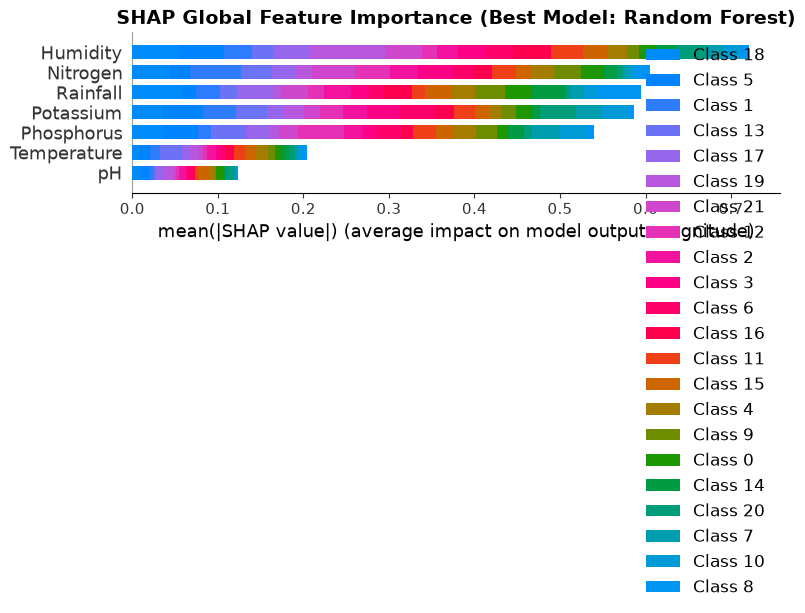

Explaining local prediction for sample 0 (Predicted Crop: Grapes)


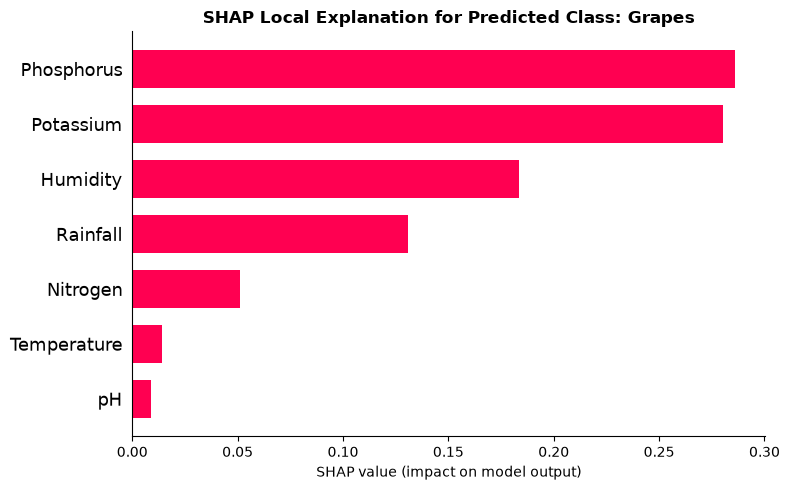

In [8]:
import shap

# Initialize SHAP TreeExplainer on the best model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values on first 100 test samples to run quickly
shap_values = explainer.shap_values(X_test[:100])
feature_list = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH', 'Rainfall']

# Global SHAP Feature Importance Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_list, plot_type="bar", show=False)
plt.title(f"SHAP Global Feature Importance (Best Model: {best_model_name})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("advanced_shap_global_importance.png", dpi=300)
plt.show()

# Local SHAP Explanation for the first test instance
test_idx = 0
sample = X_test[test_idx:test_idx+1]
predicted_class_id = best_model.predict(sample)[0]
predicted_crop = crop_names_dict[predicted_class_id]
class_idx = list(best_model.classes_).index(predicted_class_id)

print(f"Explaining local prediction for sample {test_idx} (Predicted Crop: {predicted_crop})")

plt.figure(figsize=(8, 5))
# Handle cases where shap_values might be a list or a 3D numpy array
if isinstance(shap_values, list):
    local_shap = shap_values[class_idx][test_idx]
else:
    local_shap = shap_values[test_idx, :, class_idx]

shap.bar_plot(local_shap, feature_names=feature_list, show=False)
plt.title(f"SHAP Local Explanation for Predicted Class: {predicted_crop}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("advanced_shap_local_explanation.png", dpi=300)
plt.show()

## 9. Explainable AI: LIME (Local Interpretable Model-agnostic Explanations)

LIME builds a local surrogate model to explain individual predictions on the original raw feature scale.

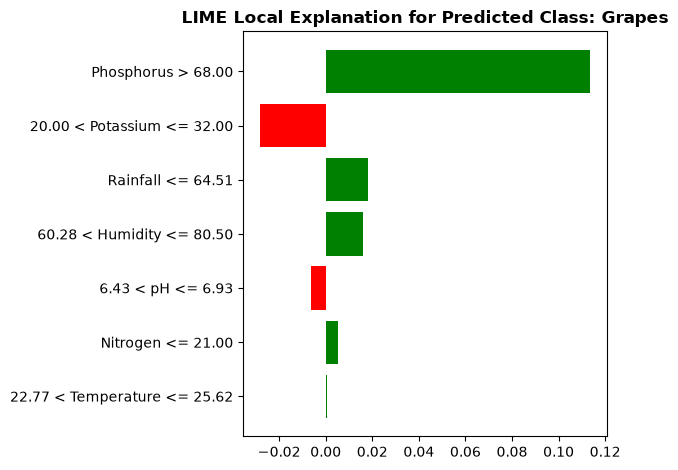

In [9]:
from lime import lime_tabular

# Reload raw features to initialize LIME in original scales
df_raw = pd.read_csv('data 2/merged_crop_recommendation.csv')
X_raw = df_raw.iloc[:, :-1].values
y_raw = df_raw.iloc[:, -1].values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

# Predict function wrapper that handles scaling before prediction
def predict_fn(x_raw):
    if len(x_raw.shape) == 1:
        x_raw = x_raw.reshape(1, -1)
    scaled = ms.transform(x_raw)
    return best_model.predict_proba(scaled)

# Initialize LIME Tabular Explainer on RAW training data
crop_names = [crop_names_dict[i] for i in sorted(crop_names_dict.keys())]
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_raw,
    feature_names=feature_list,
    class_names=crop_names,
    mode='classification'
)

# Explain the first test instance
exp = lime_explainer.explain_instance(
    data_row=X_test_raw[test_idx],
    predict_fn=predict_fn,
    num_features=7,
    labels=[class_idx]
)

# Plot LIME explanation for the predicted class
fig = exp.as_pyplot_figure(label=class_idx)
plt.title(f"LIME Local Explanation for Predicted Class: {predicted_crop}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("advanced_lime_local_explanation.png", dpi=300)
plt.show()

## 10. Predictive System with Top 3 Recommendations

In [10]:
def recommend_top_3_crops(N, P, K, temp, humidity, pH, rainfall):
    features = np.array([[N, P, K, temp, humidity, pH, rainfall]])
    scaled_features = ms.transform(features)
    
    # Get prediction probability
    probs = best_model.predict_proba(scaled_features)[0]
    top_3_indices = np.argsort(probs)[-3:][::-1]
    
    print("\n--- Top 3 Crop Recommendations (Advanced Model) ---")
    results = []
    for rank, idx in enumerate(top_3_indices, 1):
        class_id = best_model.classes_[idx]
        prob = probs[idx]
        crop_name = crop_names_dict.get(class_id, "Unknown")
        results.append((crop_name, prob))
        print(f"Rank {rank}: {crop_name} ({prob*100:.2f}% confidence)")
    return results

# Test prediction (using approximate rice conditions)
print("Testing recommendation for: N=90, P=42, K=43, Temp=21.0, Humid=82.0, pH=6.5, Rain=202.0")
_ = recommend_top_3_crops(90, 42, 43, 21.0, 82.0, 6.5, 202.0)

Testing recommendation for: N=90, P=42, K=43, Temp=21.0, Humid=82.0, pH=6.5, Rain=202.0

--- Top 3 Crop Recommendations (Advanced Model) ---
Rank 1: Rice (100.00% confidence)
Rank 2: Chickpea (0.00% confidence)
Rank 3: Maize (0.00% confidence)
